# Usage Notebook

*This document will contain the following information*

**Documentation**:

This jupyter notebook is ment to provide a form of documentation of the code (goals, implementation, (file)structure, etc.) and an example of usage of pieces of the classes, to get a clearer picture of the structure of the code. 

**Usage of the codeL**

This notebook wil contain a fairly easily usable implementation of the code, for both optimization, and building realistic versions of these optimized configurations. 

# *Documentation*

The goal of this code is to model gas cells, for laser spectroscopy. The code is fully based on object oriented programming. What follows here, is a short explanation about the file structure, and the type of classes that are included, and their functions. The full documentation will be written in another, apropiate file; the goal of this file is for my dear colleagues to get a feeling for the code, and to be able to use it. 

## File structure

The code is seperated into 6 seperate folders, which are differentiated by their role in the code. A short description of these folders and their contents. 

**Math:** These files contain the mathemathical fundation of the code. The goal is to have as few external dependencies as possible, thus this code contains its own classes of e.g. vectors and matrices. Vectors are used to provide locations and rotations to the objects inside the gas cell. Another important object in this folder are grids, which define 2 dimensional grids, used for the surface and dimensions of the mirrors and holes, to keep track of their respective hitmaps. The final class in this folder is Matrix, which contains certain standard matrices (rotations, identity, etc.), and is used to translate between *world coordinates* (3D coordinates within the cell, defined by x,y,z Vectors)  and *local coordinates* (coordinates on mirrors, defined as u and v). The folder also contains a test file.

**Geometry:** This files contains the objects needed to actually build a gas cell. This includes for example mirrors and holes. We can build mirrors and holes on a certain location and rotation (defined by vectors), but also a grid, which defines the dimensions of the mirror (has to be a TwoGrid object) and a reflection coefficient. Furthermore, Hole objects can be created, inside mirrors, which also have a location and a grid. One can add the hole to the mirror object as an input of the mirror object (however, this is not neccesairy). Furthermore, the CellGeometry is a class that defines a certain geometry of mirrors and holes. It has only 2 initial inputs, namely the name of the geometry and the dimensions of the physical cell. After the creation of this object, one can add mirror and hole objects (an inlet and outlet) to the geometry. We will use this CellGeometry object to then build a gas cell.

**Physics:** This folder includes basicly the classes surrounding the physics of the light we use in this setup. The Lightray class defines an object with a direction, intensity, but also a counter for total path length, to model a lightray in the gas cell. Furthermore, we have classes for Propagation (which move the lightray over a distance), and for reflection events on mirrors (or holes) (which give a new direction to the lightray objects). The final class in this folder is Physics.py, which basicly includes everything needed for propagation (Beer lambert for example), reflection (new direction for the ray, and intensity loss) and beam divergence.

**Results:** This set of classes defines everything needed for the analysis of the configuration. Raystate and Config are two datatype classes, which basicy combine certain information about the state of the ray (position, direction, intensity etc.) and a configuration (mirror and input ray positions/rotatios). Furthermore, the hitmap class keeps track of the positions where a hit has been registered on a mirror, on the twogrid object. Furthermore, the Trackmemory defines all the sets of raystates, to form a 'memory' of the simulations. It also has certain help methods to get information from the track memory (path length, last point, first point, etc.) Finally, the TrajectoryResults class bascily provides all analysis, given a certain track memory.

**Core:** This set of classes really is the 'motor' behind the simulation. GasCell is the class that implements the geometry, and actually runs the simulation, by shooting a lightray into the geometry, and returning a track memory. 
- A subfolder is named Optimization, including the classes we use to find working geometries (see notebook CodeDatWelWerkt.py for application). SearchSpace.py defines the parameter arrays in which the simulation will search for config's (based on three mirror config). FitnessEvaluator.py provides a score to each configuration tested, based on the amount of reflections, and how close the ray is to leaving the gas cell through the exit hole. Finally, FindingGeometry combines the previous two codes, by optimizing the Fitness (after generating random configurations within the searchspaces, and then tweeking these with small deviations to vary the fitness), with configurations within the searchspace, for a specific amount of reflections. A configuration is returned, together with the trackmemory of the final setup.
- When the optimization has been succesfull, and one has found a working geometry for a certain amount reflections, BuildGeometry is used to make a realistic version of the returned, optimized configuration (basicly with rounded numbers/finite resolution). One can then compare the optimized and rounded setups, to see how realisticly feasable the setup is (due to error propagation in the angles of the mirrors). Furthermore, some test codes are involved. 

Finally, a notebook named 'CodeDatWelWerkt' has basicly combined the three optimization codes, and applies them to get the wanted results. This has been used by me to get the wanted results for certain amounts of reflection. 

The structure of the combined classes are shown in the picture below.

*IMPORTANT: THE UNITS OF THIS MODEL ARE ALL IN DEGREES AND CM*

In [1]:
from IPython.display import Image, display
display(Image(filename='GasCellDesign2.png'))

FileNotFoundError: [Errno 2] No such file or directory: 'GasCellDesign2.png'

# Usage

What follows here is an example of how to use this model, using the optimization program and the BuildGeometry class to test te setup its realism. At each step, the code will be thouroughly explained, especially the input parameters.

### *Imports*

I think this is probably the messiest part of the code, and the imports should be fixed in future updates.

In [2]:
import csv
import sys
import os
from dataclasses import dataclass, asdict

import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import traceback

from Math.vector import Vector
from Math.matrix import Matrix
from Math.grid import TwoGrid
from Geometry.mirror import Mirror
from Geometry.hole import Hole
from Geometry.cell_geometry import CellGeometry
from Physics.lightray import Lightray
from Physics.Physics import PhysicsUtils
from Core.gas_cell import GasCell
from Results.hitmap import Hitmap
from Results.trajectory_result import TrajectoryResult, TrajectoryResultsFromCSV
from Results.Config import Config
from Core.open_csv import CSVLoader
from Core.Optimization.FindingGeometry import FindingGeometry
from Core.Build_Geometry import BuildGeometry

*Vectors and the Geometry*:
- As said before, we use Vector objects to define the positions and rotations of our mirrors.
- The origin is defined as the left bottom corner of the gas cell, such that the positions of the mirrors only have positive components.
- The rotation of m1 forms the basis for the angles: the normal of m1 is defined as 0 degrees (along the x axis).

The designs are shown in the block below.

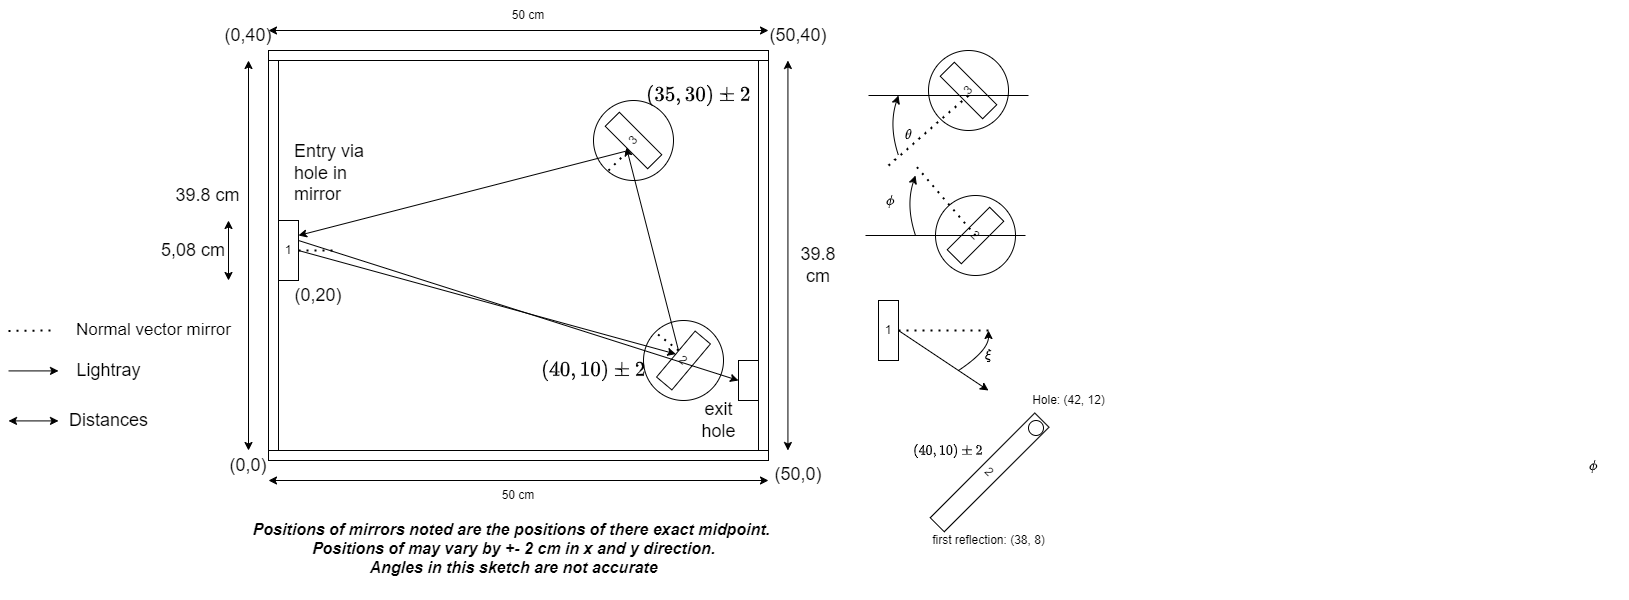

In [3]:
# Toon de afbeelding
display(Image(filename='GasCellDesign.png'))

### *Defining Parameters Optimization*

The optimization has 6 input parameters, which can be tweekend. However, try not to touch the coordinates for the first reflection, only if changes to the physical setup are needed. The same is true for the hole diameters listed, which are based on our physical holes in the mirrors



In [4]:
"""
Reflections: The amount of reflections (or target_reflections in FindingGeometry) is the amount of reflections (including the 
instance when the beam leaves the cell via the exit hole) that the users wants to have in their setup.
Crucially, one must realize that for a working cell, the amount of reflection should ALWAYS be 3n+1, where n is the
amount of circulations that the beam makes in the cell, counting from m2. 

The following amounts of reflections belong to a certain path length:
4 Reflections ~ 1.5 meters
7 Reflections ~ 2.5 meters
10 Recltections ~ 3.6 meters
13 Reflections ~ 4.6 meters
16 Reflections ~ 5.7 meters
etc. (each circulation is apprxoimatly 1-1.1 meters, depending on the exact geometry of the cell)
but... With more reflections, and more circulations, the beam will divergece more, and the system wel get more sensitive to allignment.

One must however realize that this is the TARGET amount of reflections; the optimization might find a geometry
with less or more reflections, but it will try to get as close as possible to the target amount of reflections.
"""
Reflections = 16

"""
Iterations: The amount of iterations is the amount of times the optimization will try to find a better geometry (effectively, 
although the story is a bit more complex due to the way the optimization works, but this is the general idea). The more iterations,
the better the chances of finding a working geometry, but also the longer it will take, although the optimization will stop
once it finds a working geometry. 

You may change this parameter if no working geometry is found. 
"""

iterations = 100000

"""
FirstReflectionCoordinates: The point on M2 where we want the mirror to be hit (approximatly) on the first reflection.
This is basicly the 'base' value for the angle underwhich the beam will be aimed. The optimization will then tweek this 
value a little to find a working geometry. 

Try not to change this value; physically, the idea is that the hole in M2 will be on the opposite side of the mirror (1.2, 0),
such that there is a lot of phase space left for the beam to circulate and 'move' over the surface of M2 over a number of circulations.

Note: all dimensions are in cm.
"""

FirstReflectionCoordinates = (-2, 0.0) # (u, v) coordinates on M2 for the first reflection


"""
HoleDiameters: The diameters of the entry and exit hole (in cm). Do NOT change this value, as physically, the holes will be 0.4 cm in diameter.
Maybe, at a later stage, if we need to make the hole in the mirror bigger to accomadate a larger error margin in the position of the final reflection.

"""

HoleDiameters = (0.4, 0.4) # (entry hole diameter, exit hole diameter) in cm


In [6]:
"""
Using the FindingGeometry optimization, you often need to run it a couple of times to find a working geometry. If the optimization
prints 'empty track memory' a lot, it basicly means that the optimization is stuck in some local minima (it is based on a Montecarlo method, 
so it is not guaranteed to find a working geometry in one run). In that case, just run the optimization again until you find a working geometry.

Also, for higher reflections, the chance is of course smaller that a geometry is found. Furthermore, the chance of this geometry still working in the 
next steps (rounding the numbers to a resolution of 0.01 degrees and 0.01 cm) is also smaller, due to propagation of the error margins. 
"""

finder = FindingGeometry(target_reflections=Reflections, iterations=iterations, 
                         first_reflection_u=FirstReflectionCoordinates[0], first_reflection_v=FirstReflectionCoordinates[1], 
                         hole_diameter=HoleDiameters[0], entry_hole_diameter=HoleDiameters[1]) # the optimization object

# Change save_result to True if you want to save the results of the optimization directly to a csv file. 
# There will also be an option to save AFTER the optimization is done and analyzed with finder.save_result().
best_cfg, best_mem = finder.run_optimization(save_results=False, filename_prefix="my_geometry") # running the optimization

# printing the output, which are track memory objects containing the reflection points of the best geometry found by the optimization.
if best_mem is None or not getattr(best_mem, 'memory', None): 
    print("Geen geldig spoor gevonden. Controleer of de simulatie wel reflecties produceert.")
else:
    for i, state in enumerate(best_mem.memory):
        print(f"Bounce {i+1} op {state.mirror_name}: u={state.u:.4f}, v={state.v:.4f}, Global Z={state.position.z:.4f}")
        
        
"""
The code prints a certain structure of parameters of an iteration:
- Iter: the iteration number of the optimization. Not all iterations are printed, only the ones where a new best geometry is found.
- Bounces: Amount of reflections in the geometry found in this iteration.
- Path: The pathlength of the geometry found in this iteration.
- Score: The fitness of the geometry found in this iteration. The optimization tries to maximize this score,
    which is a combination of the difference in reflections and pathlength compared to the target values.
- Acceptence: not very relevant, but it is the amount of times a geometry with a certain score is accepted as the new best geometry, 
    even if it has a lower score than the current best geometry. 
    This is a common technique in Montecarlo optimizations to avoid getting stuck in local minima (This is called simulated annealing, Lucas Sluitman
    came up with the idea to use it in this simulation, very sharp man).
"""

Start Optimalisatie | Target: 16 bounces op M2(u=1.2, v=0)
Iter      0 | Bounces:  1 | Dist: 1.8299 | Path: 46.2cm | Score:  -3943392970| acceptence: 1.000
Iter      2 | Bounces:  1 | Dist: 1.6603 | Path: 47.1cm | Score:  -3682697163| acceptence: 0.667
Iter      3 | Bounces:  1 | Dist: 1.4836 | Path: 47.0cm | Score:  -3435580173| acceptence: 0.750
Iter     10 | Bounces:  1 | Dist: 1.3674 | Path: 46.8cm | Score:  -3286740675| acceptence: 0.364
Iter     12 | Bounces:  1 | Dist: 1.3169 | Path: 46.7cm | Score:  -3225383399| acceptence: 0.385
Iter     13 | Bounces:  1 | Dist: 1.2617 | Path: 46.9cm | Score:  -3160665440| acceptence: 0.429
Iter     17 | Bounces:  1 | Dist: 1.2504 | Path: 45.8cm | Score:  -3157711307| acceptence: 0.389
Iter     20 | Bounces:  1 | Dist: 1.1407 | Path: 46.0cm | Score:  -3027330065| acceptence: 0.381
Iter     23 | Bounces:  1 | Dist: 0.1512 | Path: 45.9cm | Score:  -1435511652| acceptence: 0.375
Iter     24 | Bounces:  1 | Dist: 0.0382 | Path: 45.9cm | Score:  -1

'\nThe code prints a certain structure of parameters of an iteration:\n- Iter: the iteration number of the optimization. Not all iterations are printed, only the ones where a new best geometry is found.\n- Bounces: Amount of reflections in the geometry found in this iteration.\n- Path: The pathlength of the geometry found in this iteration.\n- Score: The fitness of the geometry found in this iteration. The optimization tries to maximize this score,\n    which is a combination of the difference in reflections and pathlength compared to the target values.\n- Acceptence: not very relevant, but it is the amount of times a geometry with a certain score is accepted as the new best geometry, \n    even if it has a lower score than the current best geometry. \n    This is a common technique in Montecarlo optimizations to avoid getting stuck in local minima (This is called simulated annealing, Lucas Sluitman\n    came up with the idea to use it in this simulation, very sharp man).\n'

In [7]:
# now we print the output of the optimization
print("\nOptimal geometry found in optimization run:")
best_cfg_config = Config(**best_cfg)
best_cfg_config.PrintConfig()
# Where the (not rounded) positions and angles are provided. 

"""
Important to notice: the angles that are measured here are NOT the angles we will physically encounter in the lab. These are angles of the relative angle
to some ideal angle, which is defined as the angle under which the beam would hit the mirror if it were perfectly aligned with the center of the mirror.
This means that the angles we will physically encounter in the lab will be the sum of these angles and the ideal angles, which are defined by the 
geometry of the cell and the position of the mirrors. This is done in a following piece of code.
"""


Optimal geometry found in optimization run:
-------Mirror 2-------
Mirror 2 Rotations: -1.7926830042073085 C
Mirror 2 Position: ( 42.13509168004101 8.505510737156257 ) cm
-------Mirror 3-------
Mirror 3 Rotations: -1.4502839529150462 C
Mirror 3 Positions: C 38.185045831192895 31.00170058871223 ) cm
-------Laser---------:
Laser pitch: -2.8035990954679324 C


'\nImportant to notice: the angles that are measured here are NOT the angles we will physically encounter in the lab. These are angles of the relative angle\nto some ideal angle, which is defined as the angle under which the beam would hit the mirror if it were perfectly aligned with the center of the mirror.\nThis means that the angles we will physically encounter in the lab will be the sum of these angles and the ideal angles, which are defined by the \ngeometry of the cell and the position of the mirrors. This is done in a following piece of code.\n'

*Analysis of the optimalization*
The TrajectoryResult class is specifically designed to analyze a given configuration and memory, which are both returned by the optimizing class. 

It includes analysis on the actual path that the beam of light has taken in the simulation, which it plotes in 2 and 3D, using the function analyze_trajectory(), which also returns the hitmaps of the mirrors. 
- When analyzing the hitmaps, especially look at 'leakage': If a beam partially is not reflected on the mirror surface, we of course lose signal. Only configurations that do not show leakage are usable. So, if one found a working configuration, one must directly test the analyze_trajectory() results.
- If there is ANY form of leakage on either the boundary of the mirror, or the entry/exit hole (before the first reflection), we have to discard the result (in 99 percent of the cases; we can deal with a little bit of signal loss...)
- It can take some time to find a configuration without leakage, so be patient... Especially for 13+ reflections.

Furthermore, it can analyze the beam diameter divergence over all reflections, and the pathlength. Finally, there is also an analysis option for the intensity analysis:
- It accounts for the loss of every reflection
- But also the loss of intensity when the beam goes through a smaller aperture then its own beam size, which is the case at the exit hole.

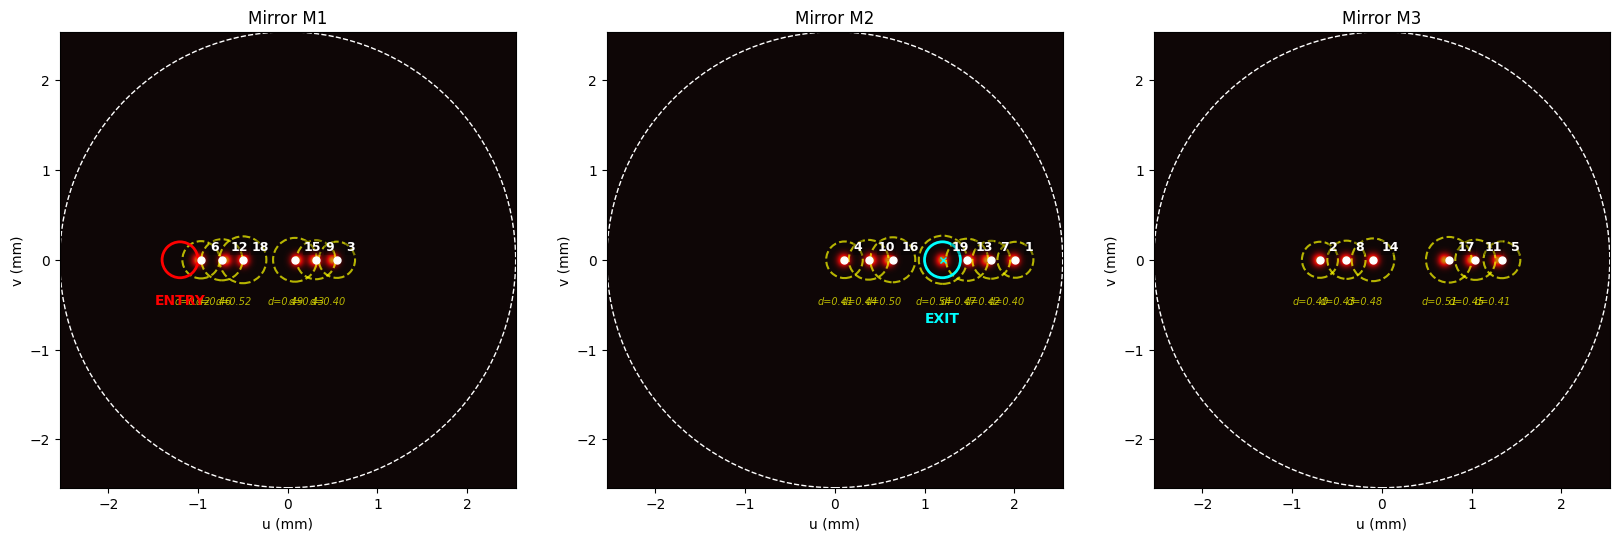

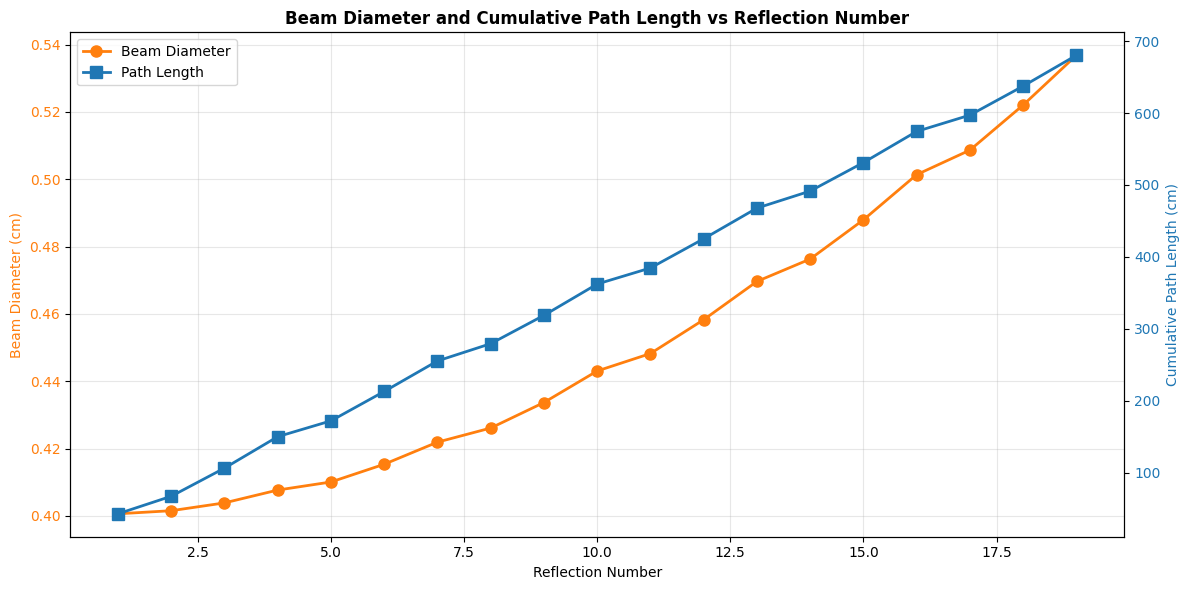

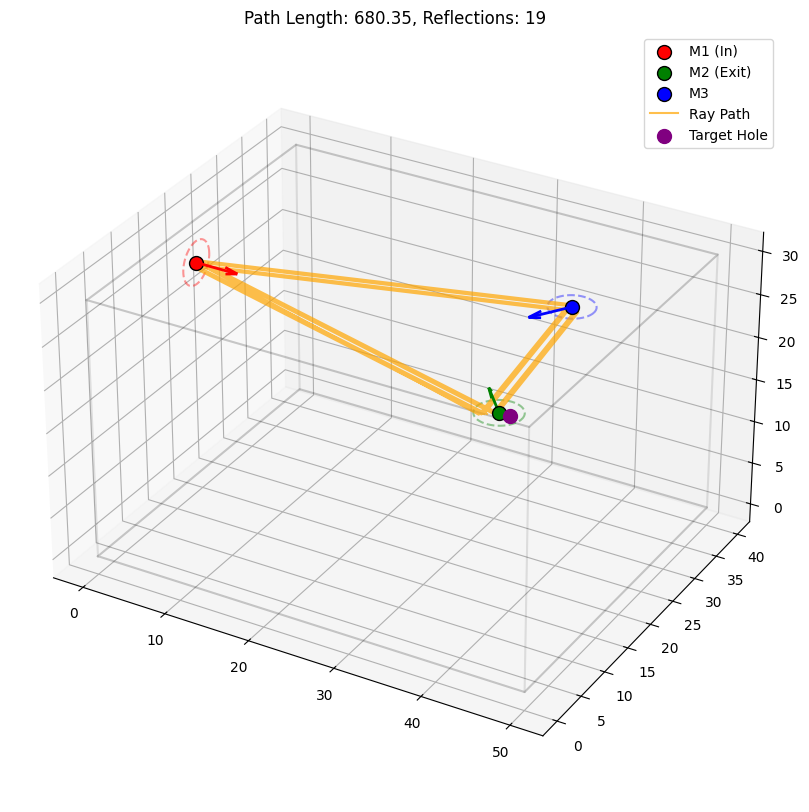

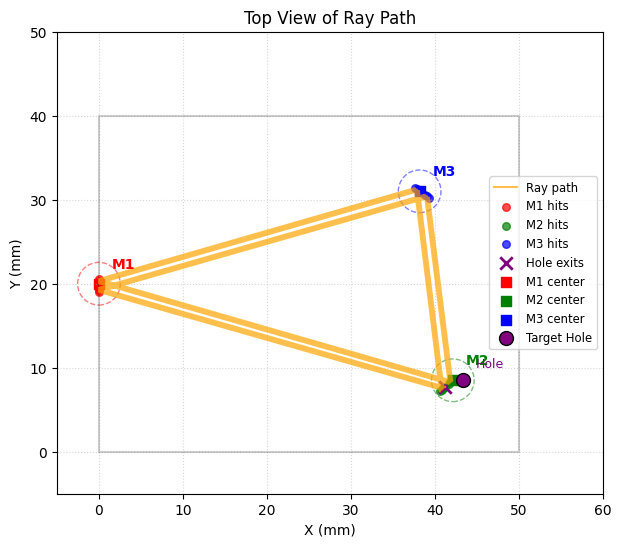

Results saved: geometry_19_config.csv and geometry_19_track_memory.csv


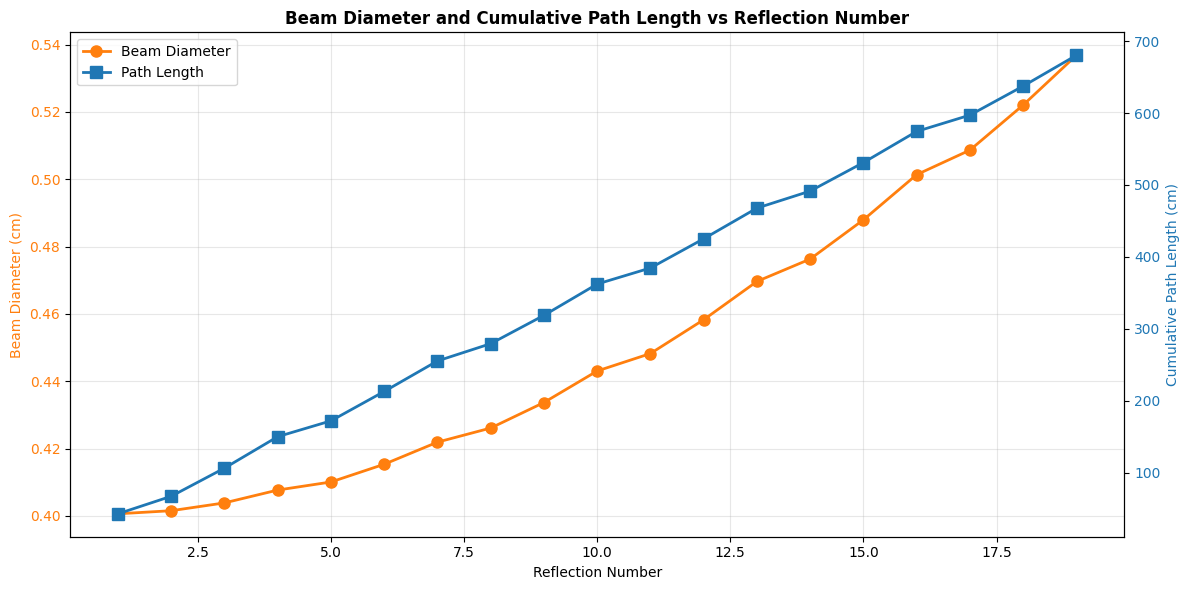

[0.40061746238789286, 0.40153394401426706, 0.40385539730071274, 0.4076706732928453, 0.41006471291497004, 0.415334144515415, 0.42189930937672065, 0.4260910863230135, 0.43367482229331455, 0.44303837133567736, 0.4482216184768884, 0.45826826903180473, 0.4696368395904428, 0.4762904253751348, 0.48793830646000397, 0.5013539605471611, 0.5086429024048174, 0.5220364588830599, 0.536817988441102]
Intensity after reflections: 0.6812326242398921
final intensity detected: 0.45682550557645774


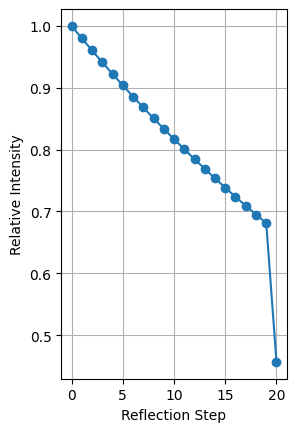

In [8]:
# the analysis of the geometry is done as follows:

# We first put the best configuration into a Config datatype object, which I unfortunatly did not integrate into the optimization initially.
best_config = Config(**best_cfg)

tr = TrajectoryResult(best_mem, best_config, grid=TwoGrid(5.08, 5.08, 0.1)) 
tr.analyze_trajectory()
tr.plot_beam_diameter_and_pathlength()
diameters = tr.calculate_beam_diameters()
print(diameters)
intensity = tr.analyze_intensity(diameters[-1])

In [8]:
# saving the results: 
finder.save_results(filename_prefix="16_reflections_test_chantal")

Results saved: 16_reflections_test_chantal_20260611_110645_16_config.csv and 16_reflections_test_chantal_20260611_110645_16_track_memory.csv


*Rounding the numbers* 

We now will be using the Class BuildGeometry, which is ment to actually translate the optimized setups, found with the optimizer, to a realistic setup. To get a more realistic setup, we of course need to round the values. We do this in the next block of codes.

The BuildGeometry class is specifically used to do this. It also has certain methods to translate the angles to the physical ones we use in the lab.

The build functions work in a bit of a silly way for this notebook; The input is a saved configuration adress. So, if you would like to build a optimized setup from the simulation above, you should chance the path that the builder uses. 
- However, when the builder object has been made, the 'build_gas_cell' can simply be used to with any config file you want, not constricted to the configuration file that was provided as the input for BuildGeometry.

In [10]:
config_file_path = "OptimizedGeometries/13Reflections/best_geometry_13_config.csv"
config_file_path1 = "16_reflections_test_chantal_20260611_110645_16_config.csv"

original_config Config(m2_x=40.49659534240897, m2_y=6.805458782758749, m3_x=35.007381669408836, m3_y=31.21929209564372, m2_phi=-0.34125499427853984, m3_theta=-0.955697326790842, ray_pitch=-1.3341425215559644, ray_yaw=0.0)
16


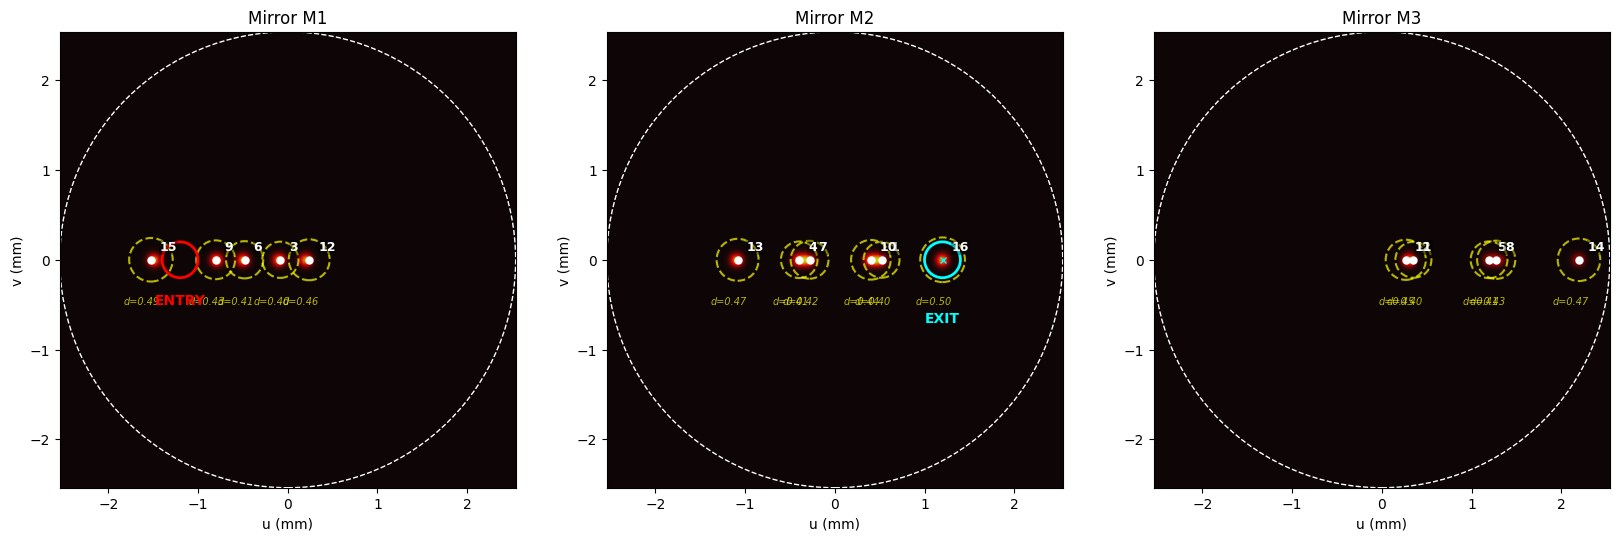

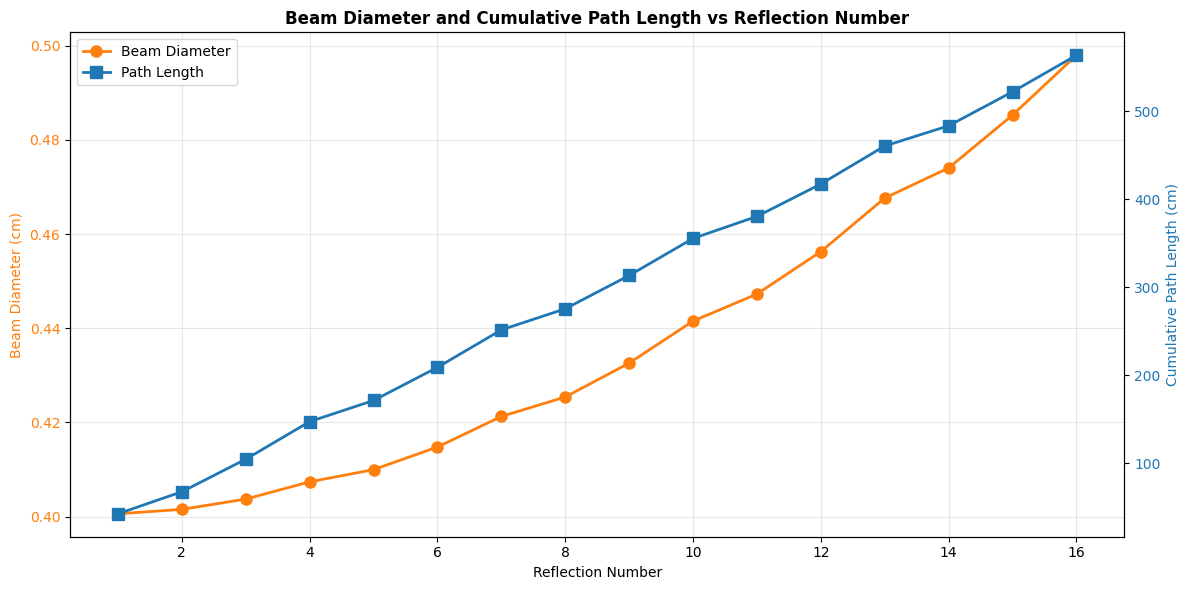

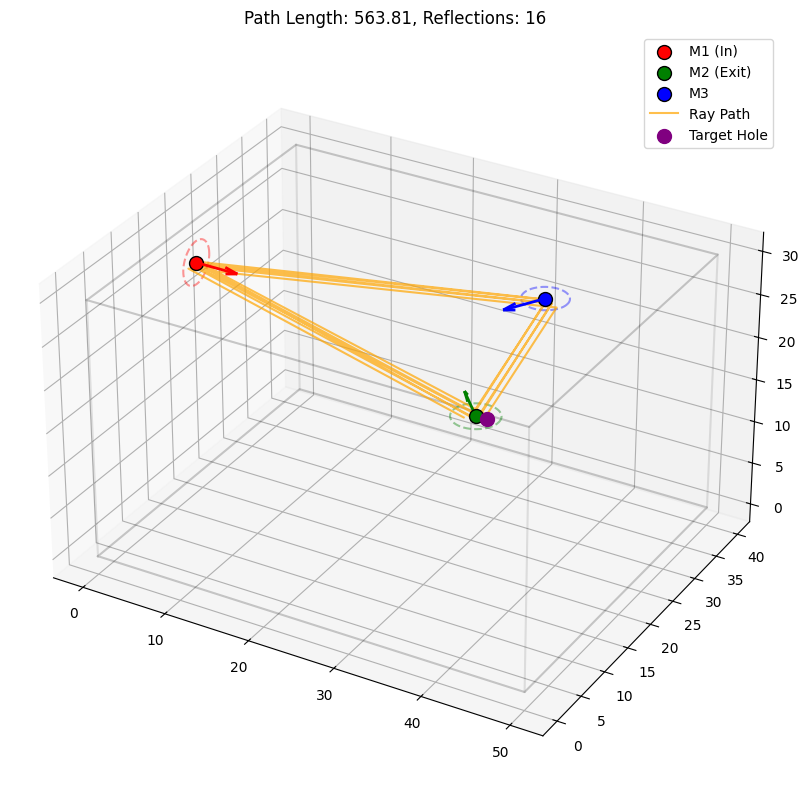

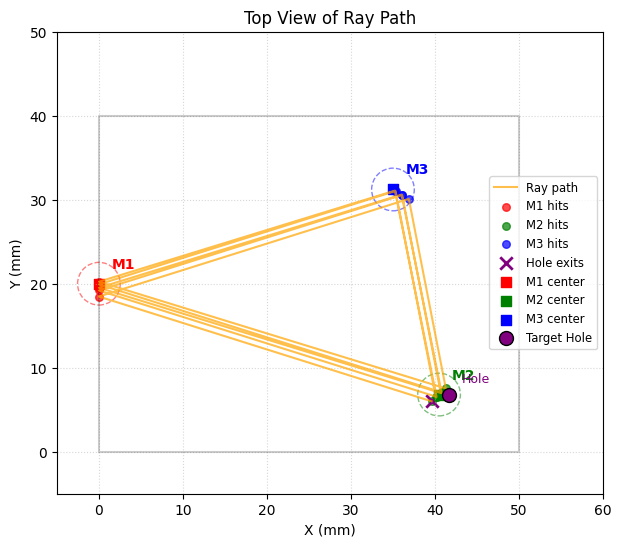

Results saved: geometry_16_config.csv and geometry_16_track_memory.csv


In [11]:
# this block builds the optimized setup
builder1 = BuildGeometry(config_file_path1)
original_config1 = builder1.read_config()
print('original_config', original_config1)
gas_cell, lightray, entry_hole_world = builder1.build_gas_cell(original_config1, first_reflection_u=-2, first_reflection_v=0.0)  

# we now simulate the setup
track_memory = builder1.run_simulation(lightray=lightray, gas_cell=gas_cell, config=original_config1)
print(len(track_memory))

# and now print all the results. This should of course return the exact same plot as above.
resultbuilder = TrajectoryResult(track_memory=track_memory, config=original_config1, grid=TwoGrid(5.08,5.08,0.10))
resultbuilder.analyze_trajectory()

*The physical angles that one has to allign in the lab are plot in the cell below*

In [12]:
translated_config = builder1.Translate_angles(original_config1)
translated_config.PrintConfig()

print('---------ROUNDED CONFIG---------- ')
# The angles that will have to be replicated in the lab:
round_translated_config = builder1.round_config(translated_config, dist_precision=2, angle_precision=2)
round_translated_config.PrintConfig()
    
# notice, the dist_precision and angle_precision are the amount of decimal we consider. the model works in cm, 
# thus a precision of 2 means we are rounding upto 0.01 cm. With the user of the fiber stages, we should be 
# able to improve this in, at least in the angles.

-------Mirror 2-------
Mirror 2 Rotations: 132.7452953874592 C
Mirror 2 Position: ( 40.49659534240897 6.805458782758749 ) cm
-------Mirror 3-------
Mirror 3 Rotations: -119.85348222297138 C
Mirror 3 Positions: C 35.007381669408836 31.21929209564372 ) cm
-------Laser---------:
Laser pitch: -20.253071440042365 C
---------ROUNDED CONFIG---------- 
-------Mirror 2-------
Mirror 2 Rotations: 132.75 C
Mirror 2 Position: ( 40.5 6.81 ) cm
-------Mirror 3-------
Mirror 3 Rotations: -119.85 C
Mirror 3 Positions: C 35.01 31.22 ) cm
-------Laser---------:
Laser pitch: -20.25 C


16


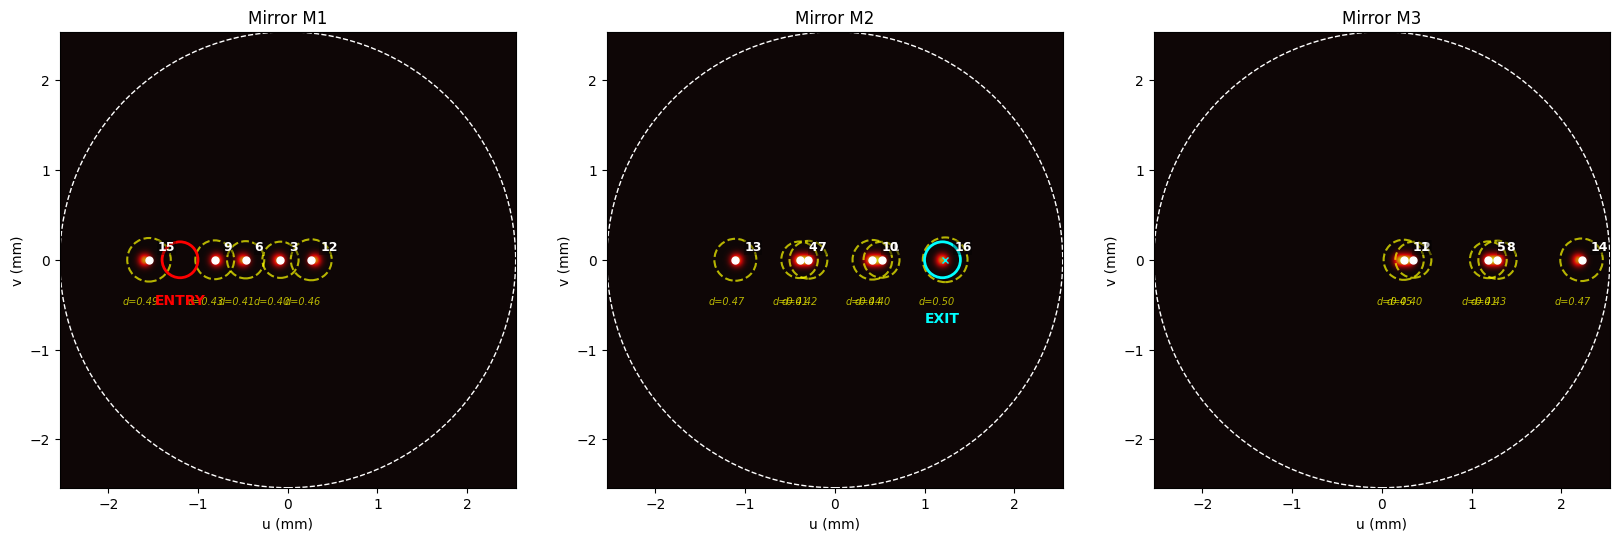

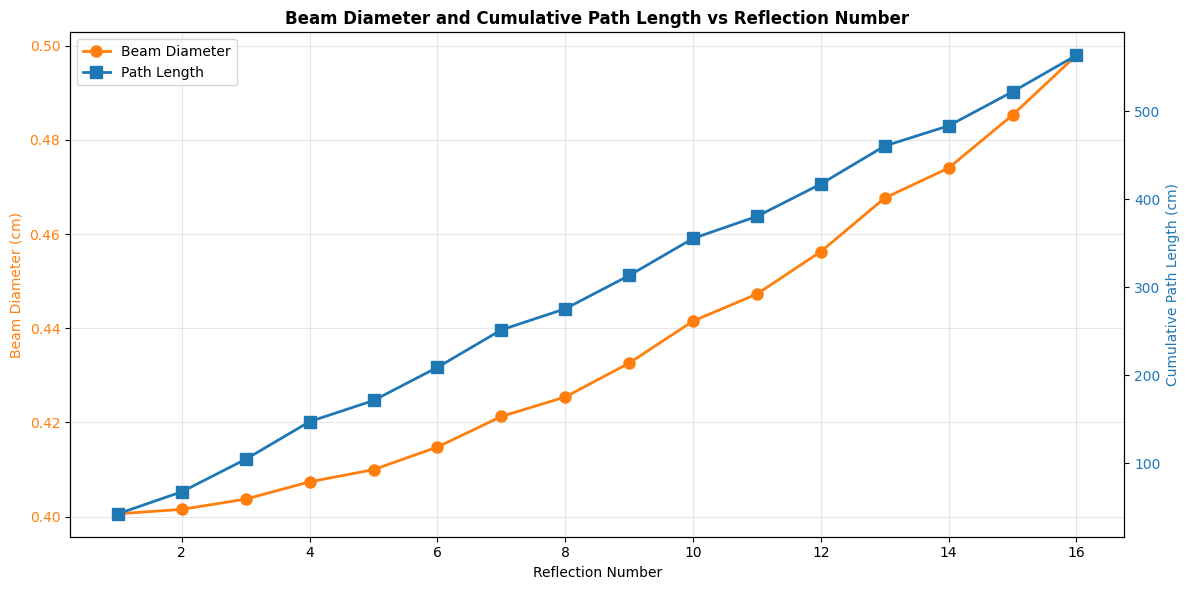

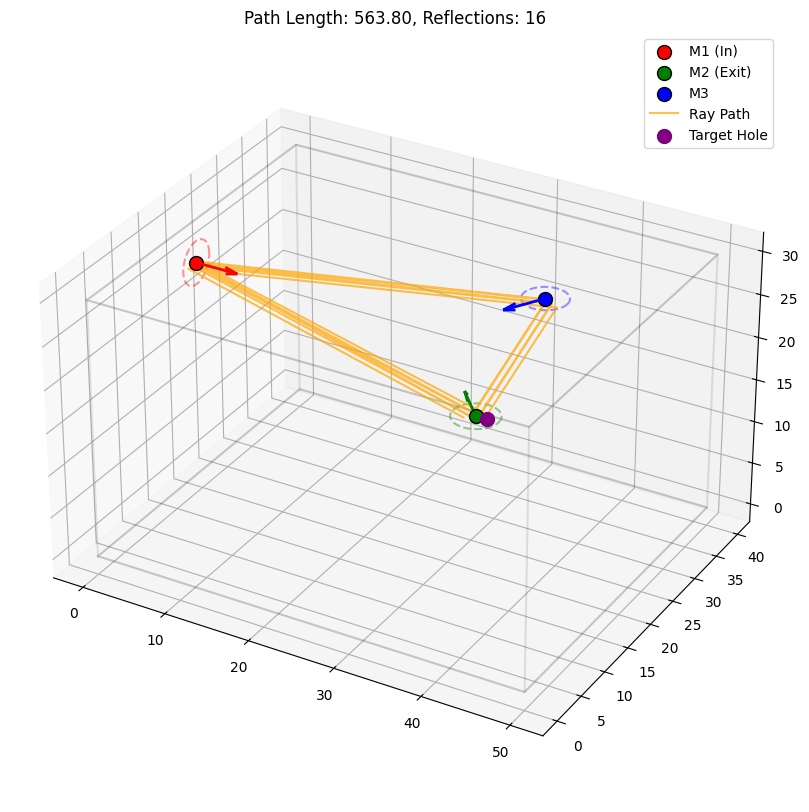

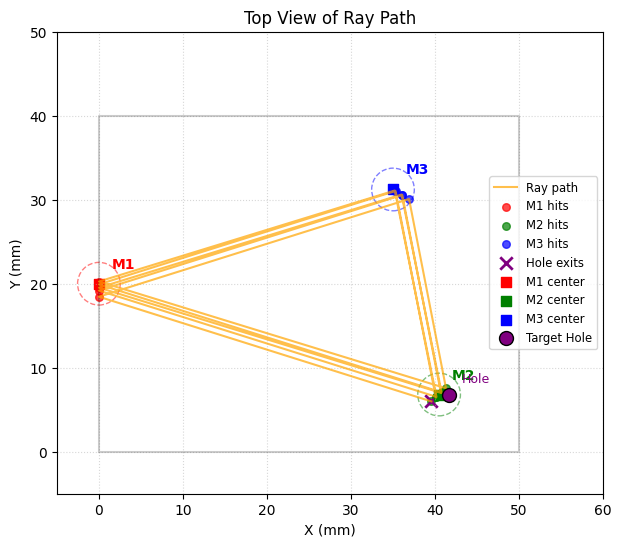

Results saved: geometry_16_config.csv and geometry_16_track_memory.csv


In [13]:
# VERY important: We do NOT use the translated angles in the building of the setup (although this is of course possible
# the code is simply not build for it). 
rounded_config = builder1.round_config(original_config1, dist_precision=2, angle_precision=3)

gas_cell_rounded, lightray_rounded, entry_hole_world = builder1.build_gas_cell(rounded_config, first_reflection_u=-2, first_reflection_v=0.0)
track_memory_rounded = builder1.run_simulation(lightray=lightray_rounded, gas_cell=gas_cell_rounded, config=rounded_config)
# I print the length of the track memory, to check the amount of events/reflections that are in the simulation.
# If the rounding of the angles and positions does work, the amount of reflections should be the same as in the unrounded simulation.
print(len(track_memory_rounded))

resultroundedbuilder = TrajectoryResult(track_memory=track_memory_rounded, config=rounded_config, grid=TwoGrid(5.08,5.08,0.10))
resultroundedbuilder.analyze_trajectory()

Now, we want to look at what happens when we shift the angle of the rounded setup by the resolution of our stage, to see what kind of marges we have, and what happens at the final reflection:
- Will the final reflection still leave via the exit hole?
- Will leakage occur? 

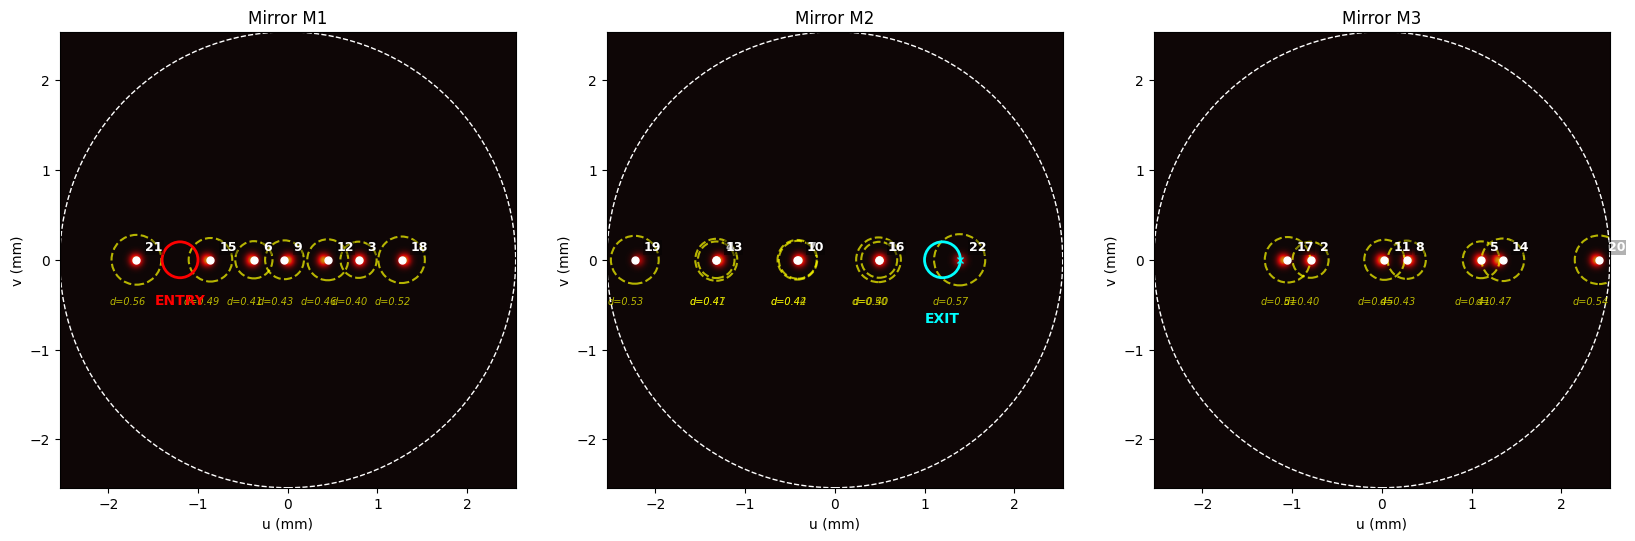

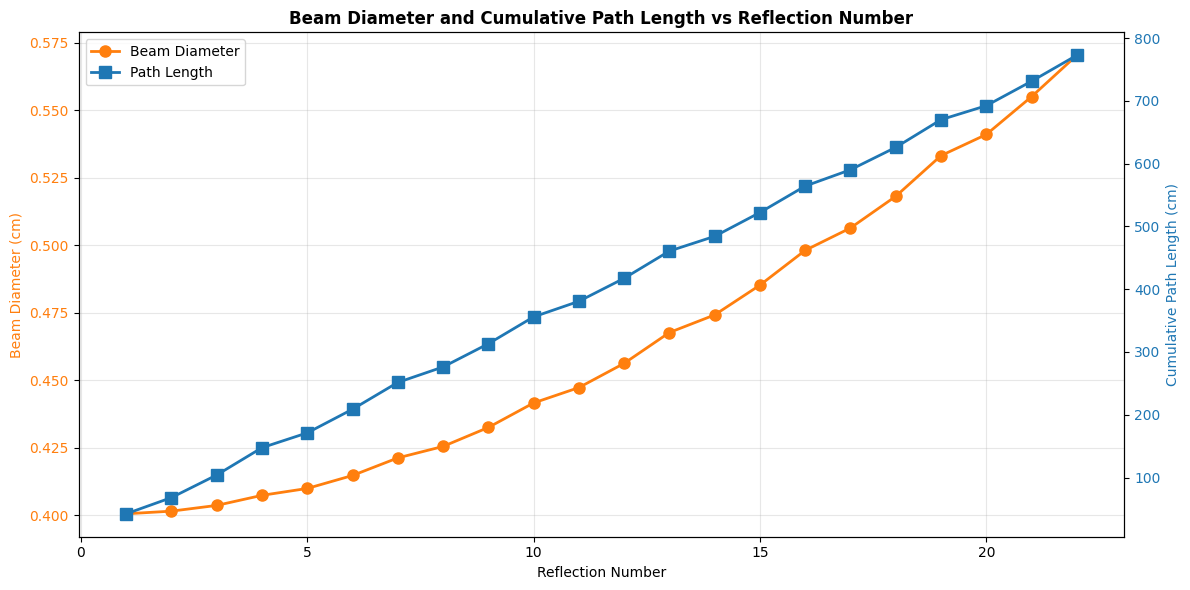

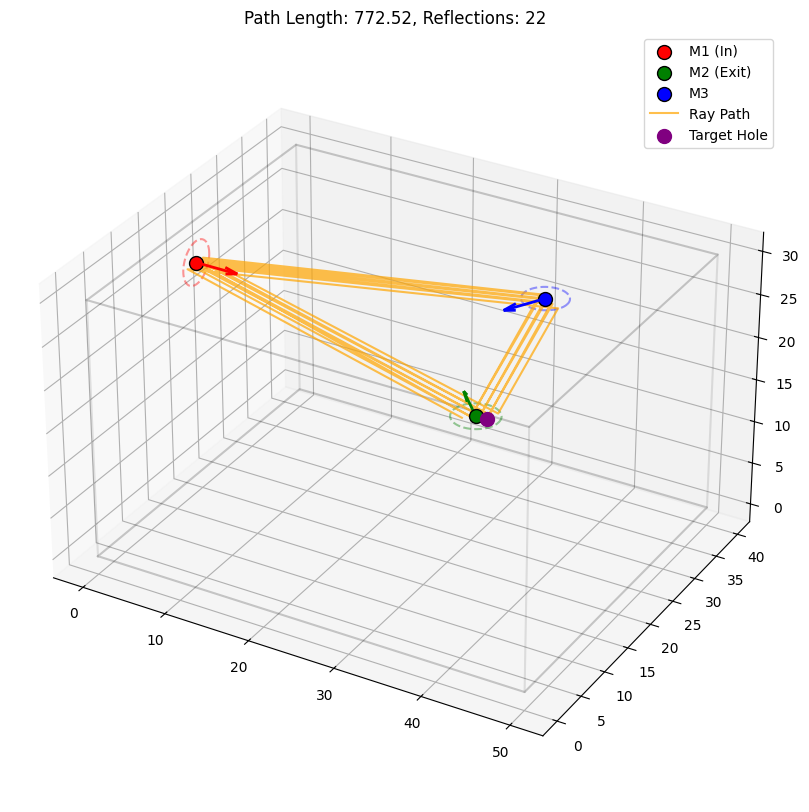

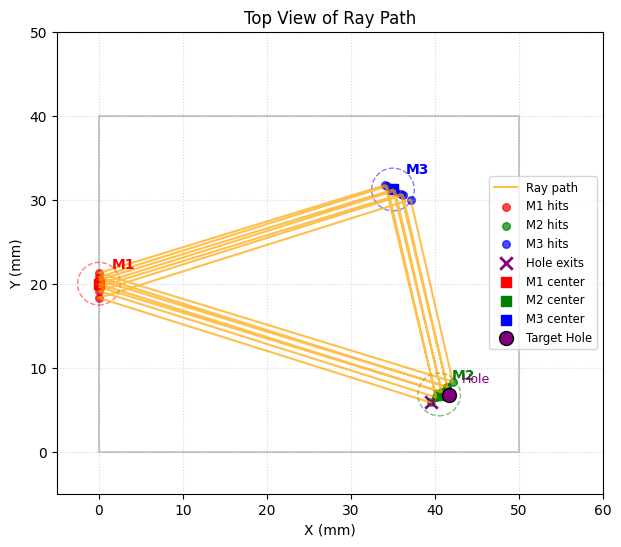

Results saved: geometry_22_config.csv and geometry_22_track_memory.csv


In [ ]:
# shift one of the angles by 0.01 degrees to see how the geometry changes.
shift = 0.01

shifted_config = Config(m2_x=rounded_config.m2_x, m2_y=rounded_config.m2_y, m2_phi=rounded_config.m2_phi + shift,
                        m3_theta = rounded_config.m3_theta + shift, m3_x = rounded_config.m3_x, m3_y=rounded_config.m3_y, 
                        ray_pitch=rounded_config.ray_pitch)

gas_cell_shifted, lightray_shifted, entry_hole_world = builder1.build_gas_cell(shifted_config, first_reflection_u=-2, first_reflection_v=0.0)
track_memory_shifted = builder1.run_simulation(lightray=lightray_shifted, gas_cell=gas_cell_shifted, config=shifted_config)
tracked_shifted = TrajectoryResult(track_memory=track_memory_shifted, config=shifted_config, grid=TwoGrid(5.08,5.08,0.10))
tracked_shifted.analyze_trajectory()

- One should look at if leakage occurs when the shift is made.
- If the setup is very sensisitive for shifts, i.e. for small misallignments in the setup, it will be a very hard challenge to allign it (which is quite trivial of course). 

I unfortunatly did not have time to make some kind of assess function for the amount of leakage, this has to be done visually by the user. Just remember: leakage before the last reflection is almost always unacceptabel, while a loss in intensity due to a smaller aperture seems almost inevitable.